<div style="background:linear-gradient(135deg,#78350f 0%,#d97706 55%,#f59e0b 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 55 · Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Hardware Lifespans: the Exponential ⏳</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">How long until a component fails? Time between random failures follows the exponential distribution. We fit the failure rate, read reliability off the CDF, and confront its strange memoryless property.</div>
  <div style="margin-top:16px;font-size:13px;color:#fed7aa">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup &amp; data

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
AMBER="#d97706"; TEAL="#0d9488"; INK="#1a2138"; GRID="#e6e9f2"; PINK="#db2777"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    df = pd.read_csv("../../data/hardware_component_lifespans.csv")
except FileNotFoundError: df = pd.read_csv(BASE+"hardware_component_lifespans.csv")
print("loaded:", df.shape)
df.head()

loaded: (1000, 4)


,component_serial,manufacture_batch,component_type,lifespan_years
0,SN_880000,BATCH_109,NVMe_Controller,11.245
1,SN_880001,BATCH_113,NVMe_Controller,1.154
2,SN_880002,BATCH_115,SSD_Drive,2.691
3,SN_880003,BATCH_136,NVMe_Controller,1.867
4,SN_880004,BATCH_110,NVMe_Controller,7.741


<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 1 · FIT THE FAILURE RATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One rate, lambda</div>
<div style="color:#4a5578;margin-top:6px">The exponential models the waiting time between Poisson events, here, between failures. Its rate lambda is one over the mean lifespan, and its right-skewed PDF lambda e^(-lambda x) drops onto the data.</div>
</div>

In [2]:
x = df["lifespan_years"]
rate = 1/x.mean()
print(f"components : {len(x):,}")
print(f"mean lifespan = {x.mean():.3f} years")
print(f"failure rate lambda = 1/mean = {rate:.4f} per year")
print(f"exponential mean = 1/lambda = {1/rate:.3f}")
print(f"exponential std  = 1/lambda = {1/rate:.3f}  (mean = std, right-skewed)")
print(f"median = ln(2)/lambda = {np.log(2)/rate:.3f} years  (< mean, the skew)")

components : 1,000
mean lifespan = 4.972 years
failure rate lambda = 1/mean = 0.2011 per year
exponential mean = 1/lambda = 4.972
exponential std  = 1/lambda = 4.972  (mean = std, right-skewed)
median = ln(2)/lambda = 3.446 years  (< mean, the skew)


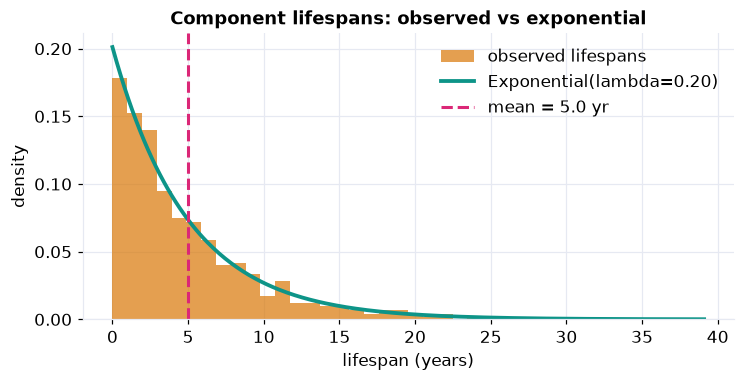

In [3]:
fig,ax=plt.subplots(figsize=(7,3.6))
ax.hist(x,bins=40,density=True,color=AMBER,alpha=0.7,label="observed lifespans")
xs=np.linspace(0,x.max(),300); ax.plot(xs,stats.expon.pdf(xs,scale=1/rate),color=TEAL,lw=2.5,label=f"Exponential(lambda={rate:.2f})")
ax.axvline(x.mean(),color=PINK,ls="--",lw=2,label=f"mean = {x.mean():.1f} yr")
ax.set_xlabel("lifespan (years)"); ax.set_ylabel("density"); ax.set_title("Component lifespans: observed vs exponential"); ax.legend()
plt.tight_layout(); plt.show()

Kolmogorov-Smirnov vs Exponential: D = 0.017, p = 0.935  -> cannot reject the fit (Exponential is a good model)


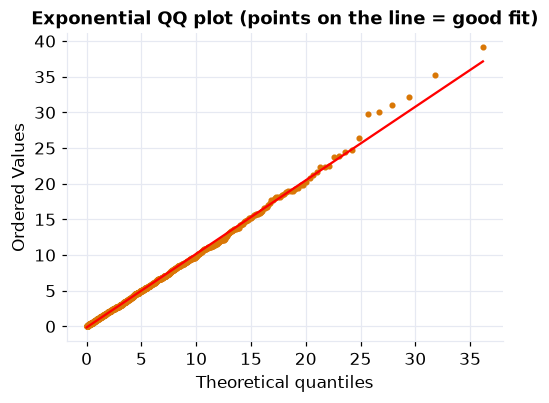

In [4]:
# Formal goodness-of-fit: does the Exponential really fit? KS test + an exponential QQ plot.
ks = stats.kstest(x, "expon", args=(0, 1/rate))
print(f"Kolmogorov-Smirnov vs Exponential: D = {ks.statistic:.3f}, p = {ks.pvalue:.3f}  -> "
      + ("cannot reject the fit (Exponential is a good model)" if ks.pvalue>0.05 else "reject: not exponential"))
fig, ax = plt.subplots(figsize=(4.8,3.8))
stats.probplot(x, dist=stats.expon, sparams=(0, 1/rate), plot=ax)
ax.get_lines()[0].set_color(AMBER); ax.get_lines()[0].set_markersize(3)
ax.set_title("Exponential QQ plot (points on the line = good fit)"); plt.tight_layout(); plt.show()

The overlay looks right, but a curve on a histogram is easy to talk yourself into. Two honest checks earn the model: the **QQ plot** lines the data's quantiles up against an exponential's (points on the diagonal = a good fit, and here they sit on it), and the formal **Kolmogorov-Smirnov** test puts a number on the gap between the data and the fitted exponential (D = 0.02, p = 0.94, so we cannot reject it). Now the Exponential is validated, not just assumed.

The exponential's right-skew fits: most parts fail early-ish, a few last a long time. Mean and standard deviation are both **5 years** (their equality is a signature), and the median, ln(2)/&#955; &#8776; 3.4 years, sits below the mean, the mark of a skewed distribution.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 2 · RELIABILITY FROM THE CDF</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Early-fatigue risk</div>
<div style="color:#4a5578;margin-top:6px">Reliability lives in the CDF: P(fails before x years) = 1 - e^(-lambda x), and its complement, the survival function e^(-lambda x), is the chance a part is still alive at age x.</div>
</div>

In [5]:
for yr in [1,2,5,10]:
    print(f"P(fails before {yr:2d} yr) = 1 - e^(-lambda*{yr}) = {stats.expon.cdf(yr,scale=1/rate):.4f}   survival {stats.expon.sf(yr,scale=1/rate):.4f}")
print(f"\nobserved early-fatigue P(<1 yr) = {(x<1).mean():.4f}")
print(f"warranty length for 5% early-failure = {stats.expon.ppf(0.05,scale=1/rate):.3f} years")

P(fails before  1 yr) = 1 - e^(-lambda*1) = 0.1822   survival 0.8178
P(fails before  2 yr) = 1 - e^(-lambda*2) = 0.3312   survival 0.6688
P(fails before  5 yr) = 1 - e^(-lambda*5) = 0.6342   survival 0.3658
P(fails before 10 yr) = 1 - e^(-lambda*10) = 0.8662   survival 0.1338

observed early-fatigue P(<1 yr) = 0.1800
warranty length for 5% early-failure = 0.255 years


About **18%** of components fail within the first year, the early-fatigue risk, matched by the data. The survival function says **37%** are still running at 5 years (= e&#8315;&#185;, since 5 years is one mean lifetime). To cap early failures at 5%, the warranty should run only about **0.26 years**, the CDF turns a risk target into a policy.

<div style="background:#fffbeb;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#b45309;letter-spacing:1px">BEAT 3 · MEMORYLESS: NO WEAR-OUT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A 5-year-old part is as good as new</div>
<div style="color:#4a5578;margin-top:6px">The exponential is memoryless: P(survives t more | survived s) = P(survives t). Its hazard rate is CONSTANT, parts do not age. We confirm by simulation, and note where the model breaks.</div>
</div>

In [6]:
rng = np.random.default_rng(55)
sim = rng.exponential(1/rate, size=2_000_000)
base = stats.expon.sf(1,scale=1/rate)
cond = np.mean(sim[sim>5] > 6)        # survived 5 years: chance of 1 more?
print(f"P(survive 1 more year, fresh part)      = {base:.4f}")
print(f"P(survive 1 more year | already 5 yr)   = {cond:.4f}  (same -> memoryless)")
print("Constant hazard: the exponential assumes no wear-out. Real parts that DO wear out need a Weibull.")

P(survive 1 more year, fresh part)      = 0.8178
P(survive 1 more year | already 5 yr)   = 0.8177  (same -> memoryless)
Constant hazard: the exponential assumes no wear-out. Real parts that DO wear out need a Weibull.


Whether a component is brand new or has run for five years, its chance of lasting one more year is the same **82%**: the exponential has no memory and a <em>constant</em> hazard rate. That is its great simplification, and its limitation: parts that genuinely wear out (rising hazard) call for the Weibull distribution. Knowing when memorylessness is and is not realistic is the engineer's judgment call.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Case closed</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Time-to-failure is exponential. We fit the rate &#955; &#8776; 0.20/year (mean 5 years), read early-fatigue risk and survival off the CDF, set a warranty from a risk target, and confronted the memoryless, constant-hazard assumption. The exponential is the continuous twin of the geometric, the waiting time of the Poisson.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>